# Black Friday Sales Data Analysis
## Part 2: Analyzing Age & Marital Status

Investigate how age groups and marital status affect purchasing behavior.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('BlackFriday.csv')

del df['Product_Category_2']
del df['Product_Category_3']

In [3]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


### Analyzing Age

In [4]:
# Number of transactions per age group
df.groupby('Age').size()

Age
0-17      14707
18-25     97634
26-35    214690
36-45    107499
46-50     44526
51-55     37618
55+       20903
dtype: int64

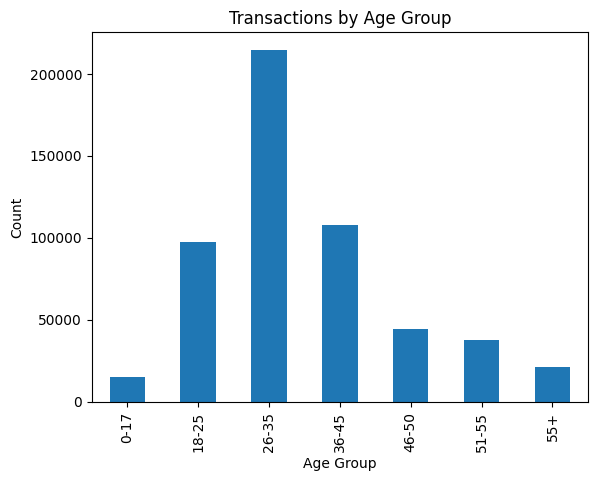

In [5]:
df.groupby('Age').size().plot(kind='bar', title='Transactions by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

In [6]:
# Find how many products each age group purchased
for i in df['Age'].unique():
    print(i, ":", len(df[df['Age'] == i]))

0-17 : 14707
55+ : 20903
26-35 : 214690
46-50 : 44526
51-55 : 37618
36-45 : 107499


18-25 : 97634


In [7]:
# Total amount spent by each age group
df.groupby('Age').sum(numeric_only=True)['Purchase']

Age
0-17      132659006
18-25     901669280
26-35    1999749106
36-45    1010649565
46-50     413418223
51-55     361908356
55+       197614842
Name: Purchase, dtype: int64

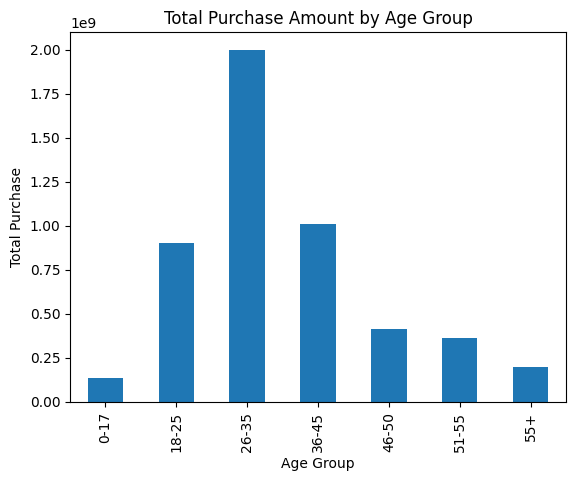

In [8]:
df.groupby('Age').sum(numeric_only=True)['Purchase'].plot(kind='bar', title='Total Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Purchase')
plt.show()

### Analyzing Marital Status

In [9]:
# Number of transactions by marital status (0 = unmarried, 1 = married)
df.groupby('Marital_Status').size()

Marital_Status
0    317817
1    219760
dtype: int64

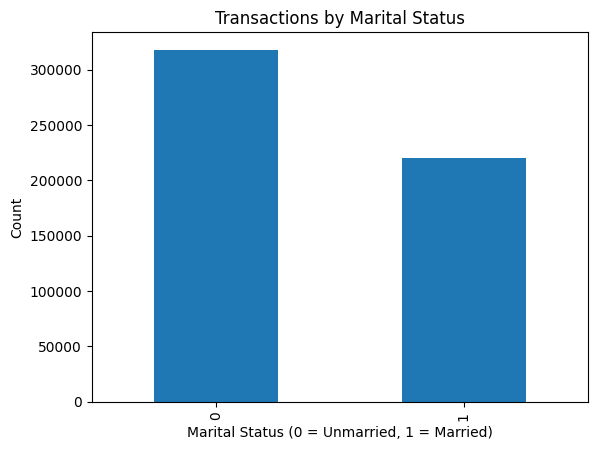

In [10]:
df.groupby('Marital_Status').size().plot(kind='bar', title='Transactions by Marital Status')
plt.xlabel('Marital Status (0 = Unmarried, 1 = Married)')
plt.ylabel('Count')
plt.show()

In [11]:
# Total and average amount spent by marital status
df.groupby('Marital_Status').sum(numeric_only=True)['Purchase']

Marital_Status
0    2966289500
1    2051378878
Name: Purchase, dtype: int64

In [12]:
df.groupby('Marital_Status').mean(numeric_only=True)['Purchase']

Marital_Status
0    9333.325467
1    9334.632681
Name: Purchase, dtype: float64

**Key takeaway:** The 26-35 age group makes the most purchases by far, and unmarried customers account for a larger share of transactions than married customers — though average spend per transaction is fairly close across both groups.